In [1]:
#@title Imports

import random
import os
import sys
import zipfile
import ee

from dataclasses import dataclass
from pathlib import Path
from google.colab import auth, drive

In [ ]:
#@title Setup

root_path = "/content/drive/MyDrive/MSc/STURM-fusion"  #@param {type:"string", multiline:true}
mount_point = "/content/drive"  #@param {type:"string"}
mount_drive = True  #@param {type:"boolean"}
clone_repo = False  #@param {type:"boolean"}

if not mount_drive and not clone_repo:
    raise ValueError("Either mount_drive or clone_repo must be True.")

repo_url = "https://github.com/TAX2310/STURM-fusion.git"

if mount_drive:
    drive.mount(mount_point)
    project_root = os.path.join(root_path, "STURM-fusion") if clone_repo else root_path
else:
    project_root = "STURM-fusion"

if clone_repo and not os.path.exists(project_root):
    !git clone {repo_url} "{project_root}"

project_root = Path(project_root)
assert project_root.exists(), f"Repo not found at {project_root}. Enable clone_repo, mount_drive, or fix root_path."

sys.path.append(str(project_root))

from config.config import CFG
cfg = CFG()
cfg.ROOT = project_root
cfg.DRIVE_ROOT = Path(mount_point) / "MyDrive" if mount_drive else project_root

print("✅ ROOT:", cfg.ROOT)
print("✅ DRIVE_ROOT:", cfg.DRIVE_ROOT)

In [ ]:
from src.data.sturm_flood import download_and_extract
from src.utils.io import save_dataframe_to_csv
from src.gee.tasks import has_active_tasks
from src.hugging_face.push_dataset import push_zip_to_hf

In [ ]:
download_and_extract(cfg)

✅ Zip already exists or dataset present, skipping download.
✅ Dataset already extracted, skipping unzip.


In [4]:
import pandas as pd

csv_path = cfg.NEW_METADATA_PATH / 'metadata.csv'

df = pd.read_csv(csv_path)

In [ ]:
#df = df[df["ems_code"] != "EMSR488"]
#df = df[df["ems_code"] != "EMSR501"]

In [5]:
from pathlib import Path
import numpy as np
import pandas as pd
import rasterio


def append_mask_pixel_counts(
    df: pd.DataFrame,
    mask_dir: str | Path,
    tile_col: str = "tile_id",
    class_values: list[int] | None = None,
) -> pd.DataFrame:
    """
    For each tile_id in df, load the corresponding flood mask and count pixel values.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe containing a tile ID column.
    mask_dir : str | Path
        Folder containing the flood mask .tif files.
    tile_col : str
        Name of the column in df containing the tile ID / filename stem.
    mask_suffix : str
        Optional suffix added after tile_id before the file extension.
        Example: tile_id='abc', mask_suffix='_mask' -> abc_mask.tif
    extension : str
        Mask file extension, default '.tif'.
    class_values : list[int] | None
        Specific class values to count. If None, uses STURM classes:
        [0, 1, 2, 3, 4, 5, 99]

    Returns
    -------
    pd.DataFrame
        Copy of df with added count columns.
    """
    mask_dir = Path(mask_dir)
    out_df = df.copy()

    if class_values is None:
        class_values = [0, 1, 2, 3, 4, 5, 99]

    count_rows = []

    for tile_id in out_df[tile_col]:
        print(tile_id)
        mask_path = mask_dir / f"{tile_id}"

        # Default row of NaNs in case file is missing
        row_counts = {f"count_{v}": np.nan for v in class_values}
        row_counts["mask_found"] = False
        row_counts["total_pixels"] = np.nan

        if mask_path.exists():
            with rasterio.open(mask_path) as src:
                mask = src.read(1)  # first band

            values, counts = np.unique(mask, return_counts=True)
            value_count_map = dict(zip(values.tolist(), counts.tolist()))

            for v in class_values:
                row_counts[f"count_{v}"] = value_count_map.get(v, 0)

            row_counts["mask_found"] = True
            row_counts["total_pixels"] = mask.size

        count_rows.append(row_counts)

    counts_df = pd.DataFrame(count_rows, index=out_df.index)
    out_df = pd.concat([out_df, counts_df], axis=1)

    return out_df

In [ ]:
df_with_counts = append_mask_pixel_counts(df,mask_dir=cfg.NEW_MASK_PATH,tile_col="tile_id")

EMSR279_04TUDELA_07_10_2_1.tif
EMSR279_04TUDELA_08_10_1_1.tif
EMSR279_04TUDELA_08_10_1_2.tif
EMSR279_04TUDELA_08_10_2_1.tif
EMSR279_04TUDELA_08_10_2_2.tif
EMSR279_04TUDELA_09_10_1_1.tif
EMSR279_04TUDELA_09_10_1_2.tif
EMSR279_04TUDELA_09_10_2_2.tif
EMSR279_04TUDELA_11_11_1_2.tif
EMSR279_04TUDELA_14_13_1_1.tif
EMSR279_04TUDELA_14_13_2_1.tif
EMSR279_04TUDELA_14_13_2_2.tif
EMSR279_04TUDELA_14_16_1_1.tif
EMSR279_04TUDELA_14_16_1_2.tif
EMSR279_04TUDELA_14_17_1_1.tif
EMSR279_04TUDELA_14_17_1_2.tif
EMSR279_04TUDELA_14_17_2_1.tif
EMSR279_04TUDELA_14_17_2_2.tif
EMSR279_04TUDELA_15_13_1_1.tif
EMSR279_04TUDELA_15_13_1_2.tif
EMSR279_04TUDELA_15_18_1_1.tif
EMSR279_04TUDELA_15_18_1_2.tif
EMSR279_04TUDELA_15_18_2_1.tif
EMSR279_04TUDELA_15_18_2_2.tif
EMSR279_05ZARAGOZA_01_02_2_2.tif
EMSR279_05ZARAGOZA_02_02_1_2.tif
EMSR279_05ZARAGOZA_02_02_2_1.tif
EMSR279_05ZARAGOZA_02_04_1_1.tif
EMSR279_05ZARAGOZA_02_04_1_2.tif
EMSR279_05ZARAGOZA_02_04_2_1.tif
EMSR279_05ZARAGOZA_02_04_2_2.tif
EMSR279_05ZARAGOZA_02_05_

In [ ]:
save_dataframe_to_csv(df_with_counts, '/content/tmp_data.csv')

✅ CSV saved to: /content/tmp_data.csv


In [ ]:
#csv_path = cfg.ROOT / 'tmp_data.csv'

#df = pd.read_csv(csv_path)

In [6]:
from pathlib import Path
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm


def convert_multi_class_mask_png(
    input_path,
    output_dir,
    colors,
    nodata=99
):
    """
    Save a multi-class flood mask as a coloured PNG.
    Output keeps same filename, changes extension to .png
    """

    input_path = Path(input_path)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    # Create output path with same name but .png
    output_path = output_dir / (input_path.stem + ".png")

    # Load mask
    with rasterio.open(input_path) as src:
        mask = src.read(1)

    # Handle NoData
    mask = mask.astype(np.float32)
    mask[mask == nodata] = np.nan

    # Create colormap
    cmap = ListedColormap(colors)

    # Define class boundaries (0,1,2,...)
    bounds = np.arange(len(colors) + 1) - 0.5
    norm = BoundaryNorm(bounds, cmap.N)

    # Plot + save
    plt.figure(figsize=(6, 6))
    plt.imshow(mask, cmap=cmap, norm=norm)
    plt.axis("off")
    plt.savefig(output_path, dpi=300, bbox_inches="tight", pad_inches=0)
    plt.close()

    return output_path

In [7]:
from pathlib import Path
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm


def convert_binary_class_mask_png(
    input_path,
    output_dir,
    colors,
    nodata=99
):
    """
    Save a binary flood mask as a coloured PNG.
    Output keeps same filename, changes extension to .png
    """

    if len(colors) != 2:
        raise ValueError("Binary mask requires exactly 2 colours")

    input_path = Path(input_path)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    # Create output path with same name but .png
    output_path = output_dir / (input_path.stem + ".png")

    # Load mask
    with rasterio.open(input_path) as src:
        mask = src.read(1)

    # Handle NoData
    mask = mask.astype(np.float32)
    mask[mask == nodata] = np.nan

    # Colormap
    cmap = ListedColormap(colors)
    bounds = [-0.5, 0.5, 1.5]
    norm = BoundaryNorm(bounds, cmap.N)

    # Plot + save
    plt.figure(figsize=(6, 6))
    plt.imshow(mask, cmap=cmap, norm=norm)
    plt.axis("off")
    plt.savefig(output_path, dpi=300, bbox_inches="tight", pad_inches=0)
    plt.close()

    return output_path

In [18]:
def convert_s1_grayscale_bands_png(
    input_path,
    output_dir,
    band_names=None
):
    """
    Save both Sentinel-1 bands as grayscale PNGs.

    Parameters
    ----------
    input_path : str | Path
        Path to input S1 .tif
    output_dir : str | Path
        Output directory
    band_names : list | None
        Optional band name suffixes, e.g. ["VV", "VH"].
        If None, uses ["band1", "band2"].

    Returns
    -------
    list[Path]
        Output file paths
    """
    input_path = Path(input_path)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    if band_names is None:
        band_names = ["VV", "VH"]

    if len(band_names) != 2:
        raise ValueError("band_names must have length 2")

    output_paths = []

    with rasterio.open(input_path) as src:
        for i in range(2):
            img = src.read(i + 1).astype(np.float32)
            img = _percentile_stretch(img)

            output_path = output_dir / f"{input_path.stem}_{band_names[i]}.png"

            plt.figure(figsize=(6, 6))
            plt.imshow(img, cmap="gray")
            plt.axis("off")
            plt.savefig(output_path, dpi=300, bbox_inches="tight", pad_inches=0)
            plt.close()

            output_paths.append(output_path)

    return output_paths

In [9]:
from pathlib import Path
import numpy as np
import rasterio
import matplotlib.pyplot as plt


def _percentile_stretch(arr, lower=2, upper=98):
    arr = arr.astype(np.float32)

    valid = np.isfinite(arr)
    if not np.any(valid):
        return np.zeros_like(arr, dtype=np.float32)

    lo = np.percentile(arr[valid], lower)
    hi = np.percentile(arr[valid], upper)

    if hi <= lo:
        return np.zeros_like(arr, dtype=np.float32)

    arr = np.clip(arr, lo, hi)
    arr = (arr - lo) / (hi - lo)
    return arr

In [10]:
from pathlib import Path
import numpy as np
import rasterio
from pathlib import Path
import numpy as np
import rasterio

def convert_mask_to_binary(
    input_path: str | Path,
    output_dir: str | Path,
    overwrite: bool = False
) -> Path:
    """
    Convert a STURM flood mask to binary and save it.

    1 = flood (any value > 0 except 99)
    0 = non-flood
    99 = NoData (preserved)

    """
    input_path = Path(input_path)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    output_path = output_dir / input_path.name

    if output_path.exists() and not overwrite:
        return output_path

    # Load mask
    with rasterio.open(input_path) as src:
        mask = src.read(1)
        profile = src.profile

    # Convert to binary
    binary = np.zeros_like(mask, dtype=np.uint8)

    binary[(mask > 0) & (mask != 99)] = 1   # flood
    binary[mask == 99] = 99                 # preserve NoData

    # Update profile
    profile.update(
        dtype=rasterio.uint8,
        count=1,
        compress="lzw",
        nodata=99
    )

    # Save
    with rasterio.open(output_path, "w", **profile) as dst:
        dst.write(binary, 1)

    return output_path

In [11]:
from pathlib import Path
import shutil


def copy_file(src_path: str | Path, dst_path: str | Path, overwrite: bool = False) -> Path:
    src_path = Path(src_path)
    dst_path = Path(dst_path)

    if not src_path.exists():
        raise FileNotFoundError(f"Source file not found: {src_path}")

    if dst_path.exists() and not overwrite:
        return dst_path

    dst_path.parent.mkdir(parents=True, exist_ok=True)

    shutil.copy2(src_path, dst_path)  # preserves metadata

    return dst_path

In [25]:
from pathlib import Path
import numpy as np
import rasterio
import matplotlib.pyplot as plt


def sentinel2_9band_tiff_to_png(
    tif_path,
    out_path=None,
    rgb_bands=(3, 2, 1),
    percentile_clip=(2, 98),
):
    """
    Convert a 9-band Sentinel-2 TIFF tile to a normal PNG for figures.

    Parameters
    ----------
    tif_path : str or Path
        Path to the 9-band TIFF.
    out_path : str or Path, optional
        Output PNG path. If None, saves next to TIFF with .png extension.
    rgb_bands : tuple
        Bands to use for RGB display. Uses 1-based indexing.
        Default (3, 2, 1) assumes visible RGB-style bands.
    percentile_clip : tuple
        Percentile stretch for nicer visualisation.

    Returns
    -------
    Path
        Path to saved PNG.
    """

    tif_path = Path(tif_path)

    if out_path is None:
        out_path = tif_path.with_suffix(".png")
    else:
        out_path = Path(out_path)

    with rasterio.open(tif_path) as src:
        img = src.read(rgb_bands)  # [3, H, W]

    # Convert to [H, W, 3]
    img = np.moveaxis(img, 0, -1).astype(np.float32)

    # Replace NaNs/infs
    img = np.nan_to_num(img, nan=0.0, posinf=0.0, neginf=0.0)

    # Percentile stretch per channel
    out = np.zeros_like(img, dtype=np.float32)

    for c in range(3):
        band = img[:, :, c]

        low, high = np.percentile(band, percentile_clip)

        if high > low:
            band = (band - low) / (high - low)
        else:
            band = np.zeros_like(band)

        out[:, :, c] = np.clip(band, 0, 1)

    plt.imsave(out_path, out)

    return out_path

In [28]:
def get_all_images(file, folder_name):
  m_c_colors = [
    "black",    # 0 background
    "blue",     # 1 flood
    "green",    # 2 river
    "cyan",     # 3 water
    "orange",   # 4 reservoir
    "purple"    # 5 lake
  ]

  b_colors = [
    "black",    # 0 background
    "blue",     # 1 flood
  ]

  copy_file(
    src_path=cfg.NEW_S1_PATH / file,
    dst_path= folder_name / ("S1/" + file),
  )

  copy_file(
    src_path=cfg.NEW_S2_PATH / file,
    dst_path= folder_name / ("S2/" + file),
  )

  copy_file(
    src_path=cfg.NEW_MASK_PATH / file,
    dst_path= folder_name / ("f_m_m/" + file),
  )

  convert_mask_to_binary(
      input_path=cfg.NEW_MASK_PATH / file ,
      output_dir= folder_name / "f_m_b",
  )

  convert_multi_class_mask_png(
    cfg.NEW_MASK_PATH / file,
    folder_name / "f_m_m/",
    m_c_colors
  )

  convert_binary_class_mask_png(
    folder_name / ("f_m_b/" + file),
    folder_name / "f_m_b/",
    b_colors
  )

  convert_s1_grayscale_bands_png(
    cfg.NEW_S1_PATH / file,
    folder_name / "S1",
    band_names=["VV", "VH"]
  )

  convert_s1_pseudo_rgb_png(
      cfg.NEW_S1_PATH / file,
      folder_name / "S1"
  )

  sentinel2_9band_tiff_to_png(
      cfg.NEW_S2_PATH / file,
      folder_name / "S2" / file.replace(".tif", ".png")
)

In [13]:
def create_image_export(images, folder_name):
  os.makedirs(folder_name, exist_ok=True)
  os.makedirs(folder_name / "S1", exist_ok=True)
  os.makedirs(folder_name / "S2", exist_ok=True)
  os.makedirs(folder_name / "f_m_m", exist_ok=True)
  os.makedirs(folder_name / "f_m_b", exist_ok=True)

  for image in images:
    get_all_images(image, folder_name)

  shutil.make_archive(folder_name, 'zip', folder_name)
  return folder_name

In [14]:
import matplotlib.pyplot as plt
from PIL import Image
import string


def create_image_grid(image_paths, captions=None, ncols=3, figsize=(12, 8), output_path=None):
    """
    Create a grid of images with captions underneath.

    Parameters
    ----------
    image_paths : list
        List of image file paths
    captions : list
        List of captions (same length as image_paths)
    ncols : int
        Number of columns
    figsize : tuple
        Figure size
    output_path : str | None
        If provided, saves the figure
    """

    if captions is None:
        letters = list(string.ascii_lowercase)

        captions = []
        for i in range(len(image_paths)):
            letter = letters[i % 26]
            repeat = (i // 26) + 1
            captions.append(f"({letter * repeat}) {image_paths[i].stem}")

    n_images = len(image_paths)
    nrows = (n_images + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = axes.flatten()

    for i, (img_path, caption) in enumerate(zip(image_paths, captions)):
        img = Image.open(img_path)

        axes[i].imshow(img)
        axes[i].axis("off")

        # Caption UNDER the image
        axes[i].set_title(caption, fontsize=10, y=-0.15)

    # Hide unused axes
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()

    if output_path:
        plt.savefig(output_path, dpi=300, bbox_inches="tight")

    plt.show()

In [15]:
def create_path_lists(images, folder_name):
  b_images = [folder_name / "f_m_b" / i for i  in images]
  m_images = [folder_name / "f_m_m" / i for i  in images]
  s1_images = [folder_name / "S1" / i for i  in images]
  s2_images = [folder_name / "S2" / i for i  in images]

  return b_images, m_images, s1_images, s2_images

#Create Figures

In [16]:
images = ['EMSR292_01CHRISOUPOLI_10_03_1_1', 'EMSR470_AOI01_33_10_1_2', 'EMSR407_AOI01_04_14_2_1', 'EMSR470_AOI01_44_09_2_1']

['EMSR292_01CHRISOUPOLI_10_03_1_1.tif', 'EMSR470_AOI01_33_10_1_2.tif', 'EMSR407_AOI01_04_14_2_1.tif', 'EMSR470_AOI01_44_09_2_1.tif']
count: 2
dtypes: ('float32', 'float32')
nodata: None
[[ 0.          0.4168885   0.47985688 ... -0.96383774 -0.4864162
  -0.10124393]
 [ 0.          0.38159177  0.43162945 ... -0.81069034 -0.32384393
  -0.10577846]
 [ 0.          0.38628507  0.44160366 ... -1.27648    -0.71900135
  -0.47244713]
 ...
 [ 0.         -2.066652   -1.6868011  ... -1.8758464  -1.6803155
  -1.6045045 ]
 [ 0.         -2.2892995  -1.8314582  ... -2.2892995  -1.9477102
  -1.6738418 ]
 [ 0.         -1.4482981  -0.79234153 ... -1.6471289  -1.7831314
  -2.0421638 ]]
[[ 0.         -0.72271734 -0.72271734 ... -0.72271734 -0.72271734
  -0.6943841 ]
 [ 0.         -0.72271734 -0.72271734 ... -0.72271734 -0.72271734
  -0.5952721 ]
 [ 0.         -0.72271734 -0.72271734 ... -0.72271734 -0.64223754
  -0.6070327 ]
 ...
 [ 0.          0.52203405 -0.20068872 ... -0.72271734 -0.72271734
  -0.7227173

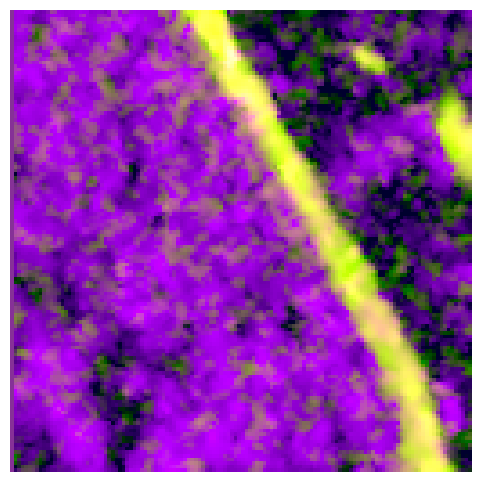

count: 2
dtypes: ('float32', 'float32')
nodata: None
[[-0.28361228  0.04371889  0.2947671  ... -0.9902156  -1.0859039
  -1.070068  ]
 [-0.1608799  -0.06592441  0.27168122 ... -0.9902598  -1.2386445
  -1.2468985 ]
 [-0.26210302 -0.30637917  0.22762065 ... -1.0427802  -1.2607657
  -1.2472857 ]
 ...
 [-1.1583204  -1.1363218  -1.219632   ...  1.0720501   1.2346554
   1.2861823 ]
 [-1.1253979  -1.2027807  -1.2674547  ...  0.9533233   1.2158194
   1.3429673 ]
 [-1.112705   -1.346867   -1.5878901  ...  0.9052822   1.2029996
   1.3823342 ]]
[[ 0.8280344   0.62294436  0.5459608  ... -0.9471934  -1.0103129
  -0.9764149 ]
 [ 1.0496298   0.7174265   0.5101996  ... -1.0823303  -0.9796593
  -0.9958233 ]
 [ 1.1902374   0.5924666   0.18464783 ... -1.5134956  -1.0567673
  -1.0782207 ]
 ...
 [-1.229487   -1.0919735  -1.0994745  ...  1.7081246   1.7930908
   1.9442638 ]
 [-1.292584   -0.9511957  -0.7827356  ...  1.7234361   1.81967
   1.9934125 ]
 [-1.2069311  -0.9732785  -0.7983284  ...  1.795113    1.8

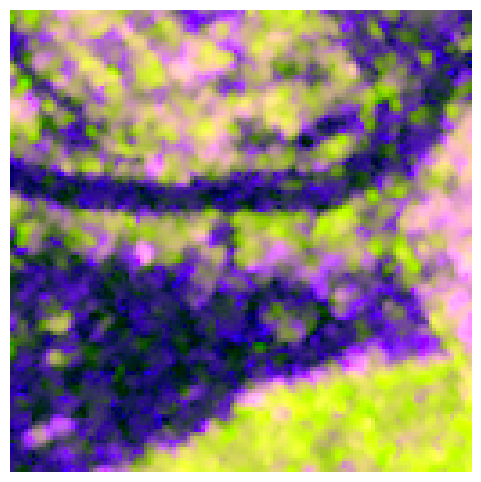

count: 2
dtypes: ('float32', 'float32')
nodata: None
[[ 0.7541675   0.5918175  -0.26553765 ... -1.0135217  -0.74093807
  -0.7616841 ]
 [ 0.7760506   0.39854652 -0.30981758 ... -1.0263199  -0.62482136
  -0.38699406]
 [ 1.0259317   0.50344706 -0.321957   ... -1.1378227  -0.6726225
  -0.4454111 ]
 ...
 [ 1.7946241   0.9575864   0.61883175 ...  0.266952   -0.6486964
  -0.7083295 ]
 [ 1.1380277   1.0842742   1.0002949  ...  0.18222208  0.0722862
  -0.611123  ]
 [ 1.071035    1.0345943   1.0990112  ...  0.53756934  0.34667274
  -0.4243106 ]]
[[ 0.82938254  0.7986897   0.3923165  ...  0.4050966   0.53102845
   0.7004742 ]
 [ 0.75300914  0.84206957 -0.04353261 ...  0.5305421   0.6407643
   0.7694852 ]
 [ 0.16662559  0.3343247  -0.19518958 ...  0.53374696  0.79640466
   0.838697  ]
 ...
 [ 0.53084147  0.76678693  0.5109099  ...  0.46912792 -0.26821846
  -0.3822887 ]
 [ 0.7103644   0.6811092   0.5439145  ...  0.6686626   0.39396363
  -0.40134692]
 [ 0.8159912   0.65144956  0.590485   ...  1.4456

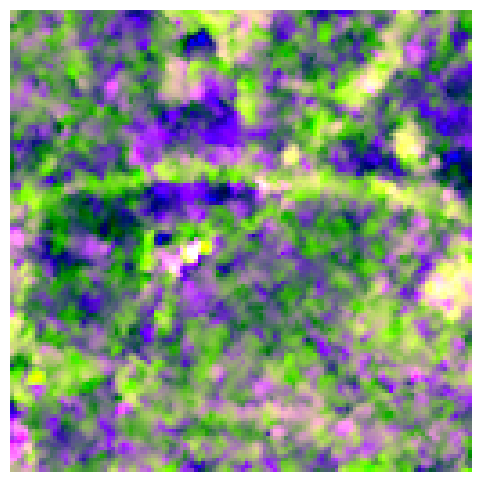

count: 2
dtypes: ('float32', 'float32')
nodata: None
[[ 1.1440754   1.1749827   1.1644961  ...  0.49277487  0.37796414
  -0.19208391]
 [ 1.1322681   1.1772078   1.174415   ...  0.7863803   0.5403968
  -0.02763318]
 [ 1.1372151   1.1928786   1.2452927  ...  0.9406271   0.93104404
   0.70658845]
 ...
 [ 1.0999025   1.1845516   1.1835165  ...  0.83351165  0.79507464
   0.57336956]
 [ 0.9391193   1.0203625   1.0507481  ...  0.7995814   0.76773596
   0.61407363]
 [ 0.6038914   0.6707774   0.856537   ...  0.56557393  0.5546399
   0.40642747]]
[[ 1.141983    1.0285807   0.9654447  ...  0.9213317   0.927821
   0.70004106]
 [ 1.044366    0.94827014  1.0062461  ...  0.90483296  0.9311008
   0.80878335]
 [ 0.88626665  0.9615363   1.077583   ...  0.88665444  0.8771956
   0.8402884 ]
 ...
 [ 1.0645915   1.3514234   1.5261946  ...  0.2408838   0.1872143
  -0.21229622]
 [ 1.0375335   1.1632701   1.3153627  ...  0.6270536   0.5143643
   0.06925394]
 [ 0.9864132   1.0208907   1.09511    ...  0.574458  

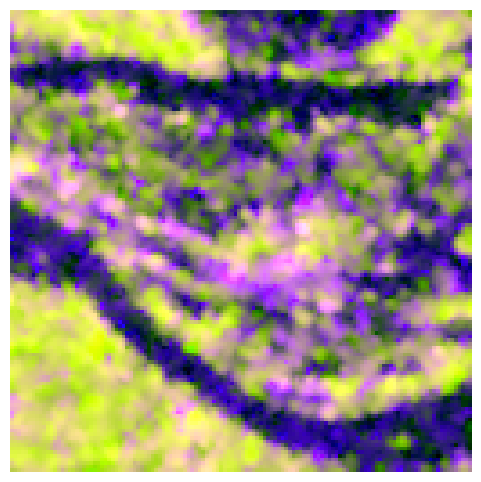

In [29]:
# Multi class distrobution
images_tif = [i + ".tif" for i  in images]
print(images_tif)

folder_name = "/content/binary_v_multi"
folder_name = Path(folder_name)

zip_file = create_image_export(images_tif, folder_name)


In [ ]:
import shutil

#files.download('/content/temp_data.zip')

['EMSR292_01CHRISOUPOLI_10_03_1_1.png', 'EMSR470_AOI01_33_10_1_2.png', 'EMSR407_AOI01_04_14_2_1.png', 'EMSR470_AOI01_44_09_2_1.png']


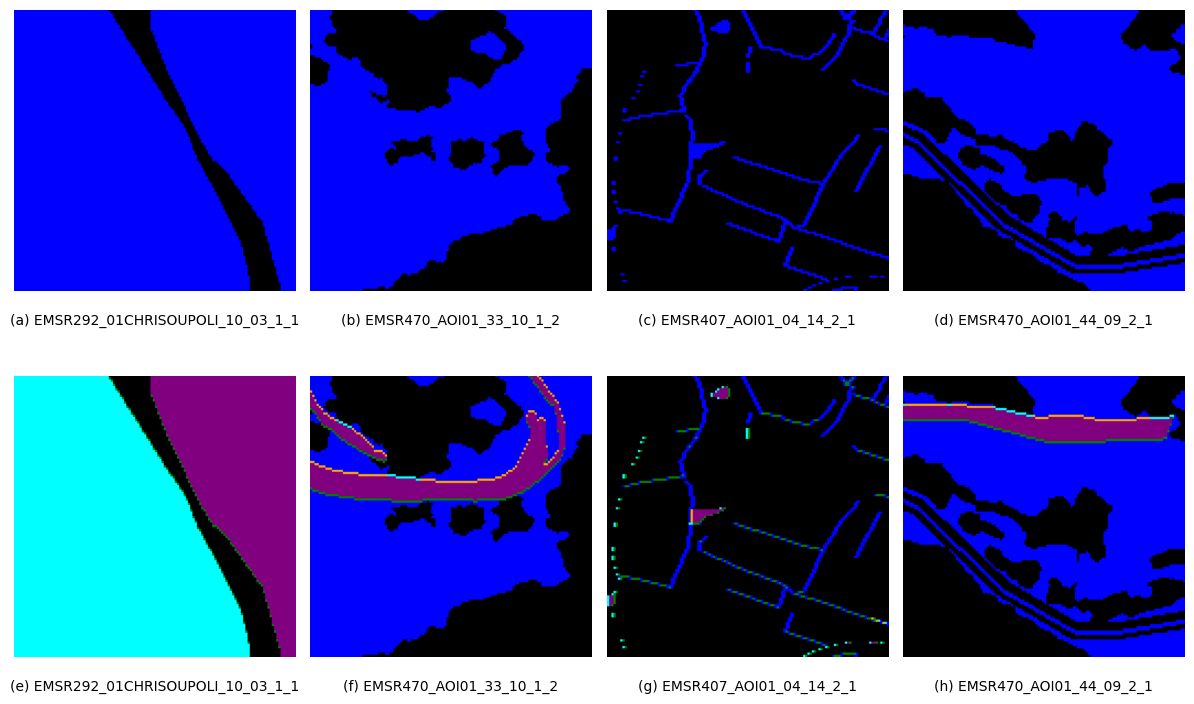

In [ ]:
images_png = [i + ".png" for i  in images]
print(images_png)

b_images, m_images, s1_images, s2_images = create_path_lists(images_png, folder_name)

create_image_grid(
    b_images + m_images,
    ncols=4,
    output_path="image_grid.png"
)

In [22]:
def convert_s1_pseudo_rgb_png(
    input_path,
    output_dir
):
    """
    Save Sentinel-1 as a pseudo-RGB PNG.

    RGB mapping:
    R = band 1
    G = band 2
    B = band 1 - band 2

    Parameters
    ----------
    input_path : str | Path
        Path to input S1 .tif
    output_dir : str | Path
        Output directory

    Returns
    -------
    Path
        Output file path
    """
    input_path = Path(input_path)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    output_path = output_dir / f"{input_path.stem}.png"

    with rasterio.open(input_path) as src:
        print("count:", src.count)
        print("dtypes:", src.dtypes)
        print("nodata:", src.nodata)

        band1 = src.read(1)
        band2 = src.read(2)
        print(band1)
        print(band2)

        print("band1 unique sample:", np.unique(band1[~np.isnan(band1)])[:20] if np.issubdtype(band1.dtype, np.floating) else np.unique(band1)[:20])
        print("band2 unique sample:", np.unique(band2[~np.isnan(band2)])[:20] if np.issubdtype(band2.dtype, np.floating) else np.unique(band2)[:20])

        print("band1 all nan:", np.isnan(band1).all() if np.issubdtype(band1.dtype, np.floating) else False)
        print("band2 all nan:", np.isnan(band2).all() if np.issubdtype(band2.dtype, np.floating) else False)

    r = _percentile_stretch(band1)
    g = _percentile_stretch(band2)
    b = _percentile_stretch(band1 - band2)

    rgb = np.dstack([r, g, b])

    plt.figure(figsize=(6, 6))
    plt.imshow(rgb)
    plt.axis("off")
    plt.savefig(output_path, dpi=300, bbox_inches="tight", pad_inches=0)
    plt.show()
    plt.close()

    return output_path

count: 2
dtypes: ('float32', 'float32')
nodata: None
[[-0.28361228  0.04371889  0.2947671  ... -0.9902156  -1.0859039
  -1.070068  ]
 [-0.1608799  -0.06592441  0.27168122 ... -0.9902598  -1.2386445
  -1.2468985 ]
 [-0.26210302 -0.30637917  0.22762065 ... -1.0427802  -1.2607657
  -1.2472857 ]
 ...
 [-1.1583204  -1.1363218  -1.219632   ...  1.0720501   1.2346554
   1.2861823 ]
 [-1.1253979  -1.2027807  -1.2674547  ...  0.9533233   1.2158194
   1.3429673 ]
 [-1.112705   -1.346867   -1.5878901  ...  0.9052822   1.2029996
   1.3823342 ]]
[[ 0.8280344   0.62294436  0.5459608  ... -0.9471934  -1.0103129
  -0.9764149 ]
 [ 1.0496298   0.7174265   0.5101996  ... -1.0823303  -0.9796593
  -0.9958233 ]
 [ 1.1902374   0.5924666   0.18464783 ... -1.5134956  -1.0567673
  -1.0782207 ]
 ...
 [-1.229487   -1.0919735  -1.0994745  ...  1.7081246   1.7930908
   1.9442638 ]
 [-1.292584   -0.9511957  -0.7827356  ...  1.7234361   1.81967
   1.9934125 ]
 [-1.2069311  -0.9732785  -0.7983284  ...  1.795113    1.8

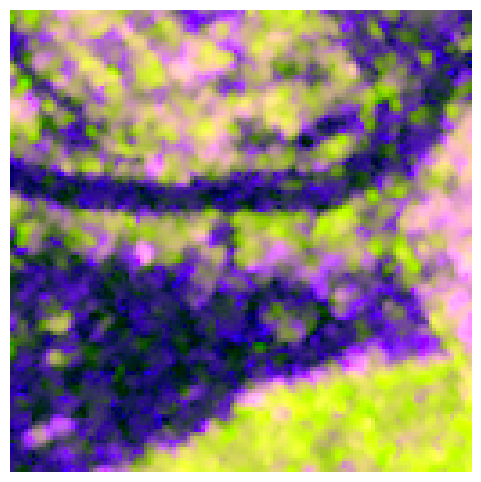

PosixPath('EMSR470_AOI01_33_10_1_2.png')

In [23]:
convert_s1_pseudo_rgb_png(
    cfg.NEW_S1_PATH / "EMSR470_AOI01_33_10_1_2.tif",
    "./"
)

In [ ]:
from pathlib import Path
import numpy as np
import rasterio


def count_nan_files(input_dir, return_files=False):
    """
    Count how many raster files contain NaN values.

    Parameters
    ----------
    input_dir : str | Path
        Directory containing .tif files
    return_files : bool
        If True, also return list of files with NaNs

    Returns
    -------
    int or (int, list)
        Number of files with NaNs
        optionally list of file paths
    """

    input_dir = Path(input_dir)

    nan_count = 0
    nan_files = []

    for file_path in input_dir.glob("*.tif"):
        with rasterio.open(file_path) as src:
            has_nan = False

            for b in range(1, src.count + 1):
                band = src.read(b)

                if np.issubdtype(band.dtype, np.floating):
                    if np.isnan(band).any():
                        has_nan = True
                        break

            if has_nan:
                nan_count += 1
                nan_files.append(file_path)

    if return_files:
        return nan_count, nan_files

    return nan_count

In [ ]:
def count_all_nan_files(input_dir):
    from pathlib import Path
    import numpy as np
    import rasterio

    input_dir = Path(input_dir)
    all_nan_files = []

    for file_path in input_dir.glob("*.tif"):
        with rasterio.open(file_path) as src:
            file_all_nan = True

            for b in range(1, src.count + 1):
                band = src.read(b)
                if np.issubdtype(band.dtype, np.floating):
                    if not np.isnan(band).all():
                        file_all_nan = False
                        break
                else:
                    file_all_nan = False
                    break

            if file_all_nan:
                all_nan_files.append(file_path)

    return len(all_nan_files), all_nan_files

In [ ]:
nan_count, nan_files = count_nan_files(cfg.NEW_S1_PATH, return_files=True)
print(f"Number of files with NaNs: {nan_count}")

Number of files with NaNs: 398


In [ ]:
nan_count, nan_files = count_all_nan_files(cfg.NEW_S1_PATH)
print(f"Number of files with all NaNs: {nan_count}")

Number of files with all NaNs: 398


In [ ]:
for file in nan_files:
  print(file.stem)

EMSR479_AOI02_34_21_2_1
EMSR501_AOI01_08_01_1_2
EMSR554_AOI03_02_03_1_2
EMSR554_AOI03_02_03_2_2
EMSR554_AOI03_02_04_1_1
EMSR554_AOI03_02_04_2_1
EMSR554_AOI03_02_04_1_2
EMSR554_AOI03_02_04_2_2
EMSR554_AOI03_02_05_1_1
EMSR554_AOI03_02_05_1_2
EMSR554_AOI03_02_05_2_2
EMSR554_AOI03_02_06_2_1
EMSR554_AOI03_02_06_2_2
EMSR554_AOI03_02_07_1_1
EMSR554_AOI03_02_07_1_2
EMSR554_AOI03_02_08_1_1
EMSR554_AOI03_02_08_2_1
EMSR554_AOI03_02_08_1_2
EMSR554_AOI03_02_09_1_1
EMSR554_AOI03_02_09_1_2
EMSR554_AOI03_02_08_2_2
EMSR554_AOI03_02_11_1_2
EMSR554_AOI03_02_09_2_1
EMSR554_AOI03_02_09_2_2
EMSR554_AOI03_02_11_1_1
EMSR554_AOI03_02_10_2_1
EMSR554_AOI03_02_11_2_2
EMSR554_AOI03_02_12_2_1
EMSR554_AOI03_02_12_1_1
EMSR554_AOI03_03_04_1_2
EMSR554_AOI03_03_04_2_1
EMSR554_AOI03_03_04_1_1
EMSR554_AOI03_03_03_2_2
EMSR554_AOI03_03_03_1_2
EMSR554_AOI03_03_05_1_2
EMSR554_AOI03_03_04_2_2
EMSR554_AOI03_03_05_2_2
EMSR554_AOI03_03_05_2_1
EMSR554_AOI03_03_06_1_1
EMSR554_AOI03_03_06_1_2
EMSR554_AOI03_03_07_2_2
EMSR554_AOI03_03

In [ ]:
EMSR292_01CHRISOUPOLI_10_03_1_1 EMSR470_AOI01_33_10_1_2 EMSR407_AOI01_04_14_2_1 EMSR470_AOI01_44_09_2_1